# MultiGNBWrapper — Test Notebook

Structure:
1. **Part A — Mock NodeB stubs** (no external dependencies)
   - 1.1 Sanity checks: reset / step / spaces
   - 1.2 UE mobility & handover visualisation
2. **Part B — Real NodeB** (requires full slice stack)
   - 2.1 Sanity checks with actual slices
   - 2.2 UE mobility & handover visualisation

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import warnings
warnings.filterwarnings('ignore')

# Make sure the wrapper is importable (adjust path if needed)
import sys
sys.path.insert(0, '.')   # add current directory

from multi_gnb_wrapper import MultiGNBWrapper

---
## Part A — Mock NodeB Stubs
Self-contained stubs that mimic the NodeB interface so you can run every test
without importing any slice or channel-model code.

In [33]:
class MockSliceL1:
    """Minimal slice stub — just enough for MultiGNBWrapper."""
    def __init__(self, n_prbs=50, n_state_vars=4):
        self.n_prbs = n_prbs
        self._n_vars = n_state_vars

    def reset(self): pass
    def reset_info(self): pass
    def get_n_variables(self): return self._n_vars
    def set_prbs(self, i_prb, n_prbs): self.n_prbs = n_prbs
    def get_state(self): return np.random.rand(self._n_vars).astype(np.float32)
    def get_info(self): return {}
    def compute_reward(self): return (1, 0)   # (reward, violations)
    def slot(self): pass


class MockNodeB:
    """
    Stub NodeB that exposes the same interface as the real NodeB
    without any radio-stack dependencies.
    """
    def __init__(self, id, x, y, n_prbs=100, coverage_radius=500,
                 n_slices=2, n_state_vars=4, slots_per_step=50):
        self.id = id
        self.x = x
        self.y = y
        self.n_prbs = n_prbs
        self.coverage_radius = coverage_radius
        self.slots_per_step = slots_per_step
        self.slices_l1 = [MockSliceL1(n_prbs // n_slices, n_state_vars)
                          for _ in range(n_slices)]
        self.n_slices_l1 = n_slices
        self._state_dim = 2 + n_slices * n_state_vars  # x,y + slices
        self._steps = 0

    def reset(self):
        self._steps = 0
        return self.get_state()

    def get_state(self):
        base = np.array([self.x, self.y], dtype=np.float32)
        slices = np.concatenate([s.get_state() for s in self.slices_l1])
        return np.concatenate([base, slices])

    def compute_reward(self):
        rewards   = np.array([s.compute_reward()[0] for s in self.slices_l1])
        violations = np.array([s.compute_reward()[1] for s in self.slices_l1])
        return rewards, violations

    def step(self, action):
        self._steps += 1
        return self.get_state(), {'n_prbs': [s.n_prbs for s in self.slices_l1]}

    def get_info(self, violations=0, SLA_labels=0):
        return {'n_prbs': [s.n_prbs for s in self.slices_l1],
                'violations': violations, 'SLA_labels': SLA_labels}

    def __repr__(self):
        return f'MockNodeB {self.id} at ({self.x},{self.y})'

### A.1 — Sanity Checks: reset / step / spaces

In [34]:
# ── Build a 3-gNB environment with mock stubs ──────────────────────────────
mock_gnbs = [
    MockNodeB(id=0, x=200, y=400, n_prbs=100, coverage_radius=350, n_slices=2),
    MockNodeB(id=1, x=600, y=400, n_prbs=100, coverage_radius=350, n_slices=2),
    MockNodeB(id=2, x=400, y=100, n_prbs=100, coverage_radius=350, n_slices=2),
]

env = MultiGNBWrapper(
    gnb_list=mock_gnbs,
    slots_per_step=50,
    handover_hysteresis=0.05,
    handover_ttt=3,
    verbose=True,
)

print('Observation space:', env.observation_space)
print('Action space     :', env.action_space)
print(f'obs_dim = {env.observation_space.shape[0]}')
print(f'act_dim = {env.action_space.shape[0]}')

Observation space: Box(-inf, inf, (30,), float32)
Action space     : Box(0.0, 1.0, (6,), float32)
obs_dim = 30
act_dim = 6


In [35]:
# ── reset() ────────────────────────────────────────────────────────────────
obs, info = env.reset(seed=42)

assert obs.shape == env.observation_space.shape, "obs shape mismatch after reset"
assert obs.dtype == np.float32, "obs dtype should be float32"
print(f'reset() OK — obs shape {obs.shape}, dtype {obs.dtype}')
print(f'obs[:6] = {obs[:6]}')

reset() OK — obs shape (30,), dtype float32
obs[:6] = [2.0000000e+02 4.0000000e+02 7.0291299e-01 7.2717851e-01 2.0354669e-01
 5.8735842e-01]


In [36]:
# ── step() with random actions ─────────────────────────────────────────────
rng = np.random.default_rng(0)
n_steps = 10
rewards = []

obs, _ = env.reset()
for i in range(n_steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    assert obs.shape == env.observation_space.shape, f"obs shape mismatch at step {i}"
    assert isinstance(reward, float), f"reward should be float, got {type(reward)}"

print(f'step() OK — ran {n_steps} steps without error')
print(f'rewards: {[round(r,3) for r in rewards]}')
print(f'info keys: {list(info.keys())}')

step() OK — ran 10 steps without error
rewards: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
info keys: ['gnb_0', 'gnb_1', 'gnb_2', 'per_gnb_rewards', 'handover_count', 'ue_per_gnb']


In [37]:
# ── PRB allocation sanity: slices in each gNB must sum to n_prbs ───────────
obs, _ = env.reset()
action = env.action_space.sample()
_, _, _, _, info = env.step(action)

for i, gnb in enumerate(env.gnbs):
    allocated = sum(s.n_prbs for s in gnb.slices_l1)
    total     = gnb.n_prbs
    status    = '✓' if allocated == total else '✗'
    print(f'  gNB {gnb.id}: allocated={allocated}  total={total}  {status}')

print('PRB allocation check complete')

  gNB 0: allocated=100  total=100  ✓
  gNB 1: allocated=100  total=100  ✓
  gNB 2: allocated=100  total=100  ✓
PRB allocation check complete


### A.2 — UE Mobility & Handover Visualisation

In [38]:
def hex_vertices(cx, cy, r):
    """Return (6,2) array of hexagon vertices centred at (cx,cy) with circumradius r."""
    angles = np.radians(np.arange(6) * 60)
    return np.column_stack([cx + r * np.cos(angles), cy + r * np.sin(angles)])


def draw_cells(ax, gnbs, colors=None, alpha=0.15):
    """Draw hexagonal cells for a list of NodeB-like objects."""
    colors = colors or plt.cm.tab10.colors
    for i, gnb in enumerate(gnbs):
        verts = hex_vertices(gnb.x, gnb.y, gnb.coverage_radius)
        patch = Polygon(verts, closed=True,
                        facecolor=colors[i % len(colors)], alpha=alpha,
                        edgecolor=colors[i % len(colors)], linewidth=2)
        ax.add_patch(patch)
        ax.plot(gnb.x, gnb.y, '^', color=colors[i % len(colors)],
                markersize=12, zorder=5)
        ax.text(gnb.x, gnb.y + 25, f'gNB {gnb.id}', ha='center',
                fontsize=9, fontweight='bold', color=colors[i % len(colors)])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')

In [39]:
# ── Simulate UE mobility across cells ──────────────────────────────────────
env2 = MultiGNBWrapper(
    gnb_list=[
        MockNodeB(id=0, x=200, y=300, coverage_radius=300),
        MockNodeB(id=1, x=600, y=300, coverage_radius=300),
    ],
    slots_per_step=50,
    handover_hysteresis=0.04,
    handover_ttt=2,
    verbose=False,
)
env2.reset()

# UE starts near gNB 0 and moves toward gNB 1
ue_id = env2.add_ue(x=50, y=300, vx=8.0, vy=0.0)

N_STEPS = 60
trajectory  = []   # (x, y)
serving_log = []   # serving gNB index at each step
ho_steps    = []   # steps where HO fired

for step in range(N_STEPS):
    action = env2.action_space.sample()
    env2.step(action)

    ue = env2._ues[ue_id]
    trajectory.append((ue['x'], ue['y']))
    serving_log.append(ue['serving_gnb'])

# Find steps where the serving gNB changed
for i in range(1, len(serving_log)):
    if serving_log[i] != serving_log[i-1] and serving_log[i] is not None:
        ho_steps.append(i)

print(f'Simulation complete — {N_STEPS} steps')
print(f'Handover events logged: {len(env2.handover_log)}')
for ev in env2.handover_log:
    print(f"  step {ev['step']:>3d}: UE {ev['ue_id']} gNB {ev['from_gnb']} → {ev['to_gnb']}")

Simulation complete — 60 steps
Handover events logged: 0


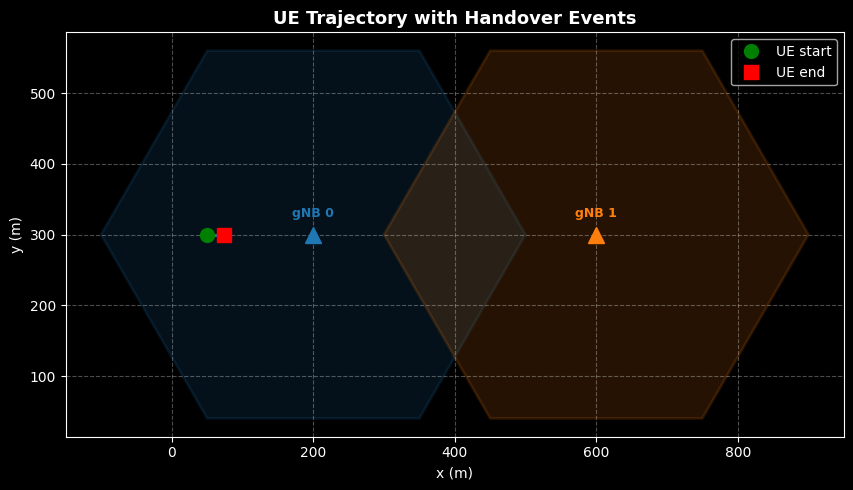

In [40]:
# ── Plot 1: UE trajectory with handover marker ─────────────────────────────
COLORS = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 5))
draw_cells(ax, env2.gnbs, colors=COLORS)

xs = [p[0] for p in trajectory]
ys = [p[1] for p in trajectory]

# Colour trajectory by serving gNB
for i in range(len(trajectory) - 1):
    s = serving_log[i]
    c = COLORS[s] if s is not None else 'gray'
    ax.plot(xs[i:i+2], ys[i:i+2], '-', color=c, linewidth=2, alpha=0.7)

# Start / end markers
ax.plot(xs[0], ys[0], 'go', markersize=10, zorder=6, label='UE start')
ax.plot(xs[-1], ys[-1], 'rs', markersize=10, zorder=6, label='UE end')

# Handover markers
for ho_step in ho_steps:
    ax.axvline(xs[ho_step], color='black', linestyle=':', alpha=0.5)
    ax.plot(xs[ho_step], ys[ho_step], 'k*', markersize=14, zorder=7,
            label='Handover' if ho_step == ho_steps[0] else '')

ax.set_title('UE Trajectory with Handover Events', fontsize=13, fontweight='bold')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.legend()
plt.tight_layout()
plt.show()

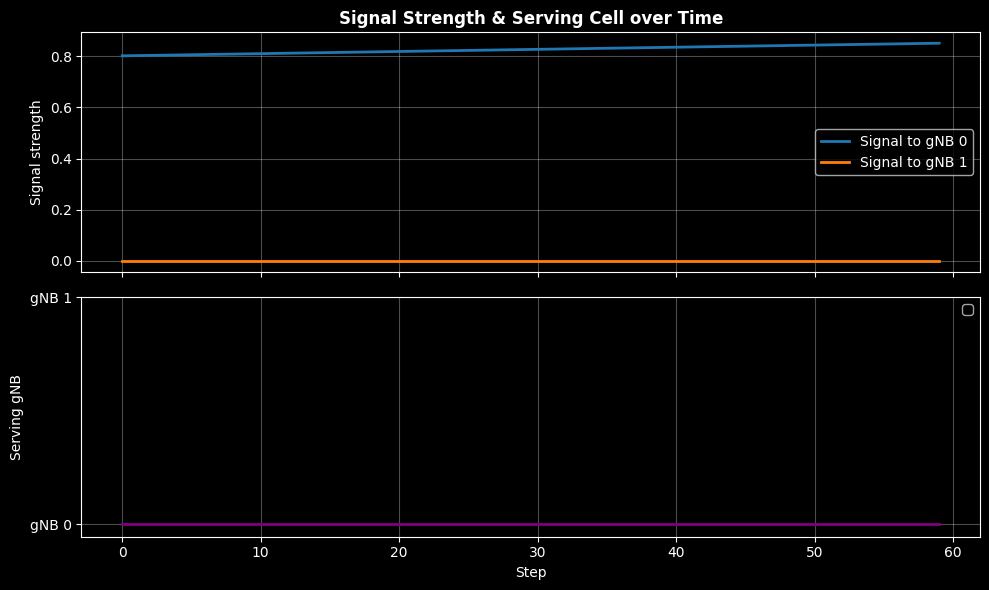

In [41]:
# ── Plot 2: Signal strength vs step + serving gNB timeline ────────────────
from multi_gnb_wrapper import _signal_strength   # internal helper

sig0, sig1 = [], []
for (x, y) in trajectory:
    g0, g1 = env2.gnbs
    sig0.append(_signal_strength(np.hypot(x - g0.x, y - g0.y), g0.coverage_radius))
    sig1.append(_signal_strength(np.hypot(x - g1.x, y - g1.y), g1.coverage_radius))

steps = np.arange(N_STEPS)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Signal strengths
ax1.plot(steps, sig0, label='Signal to gNB 0', color=COLORS[0], linewidth=2)
ax1.plot(steps, sig1, label='Signal to gNB 1', color=COLORS[1], linewidth=2)
for ho_step in ho_steps:
    ax1.axvline(ho_step, color='black', linestyle=':', alpha=0.6)
ax1.set_ylabel('Signal strength')
ax1.set_title('Signal Strength & Serving Cell over Time', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Serving gNB
serving_numeric = [s if s is not None else -1 for s in serving_log]
ax2.step(steps, serving_numeric, where='post', color='purple', linewidth=2)
for ho_step in ho_steps:
    ax2.axvline(ho_step, color='black', linestyle=':', alpha=0.6, label='HO' if ho_step == ho_steps[0] else '')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['gNB 0', 'gNB 1'])
ax2.set_ylabel('Serving gNB')
ax2.set_xlabel('Step')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

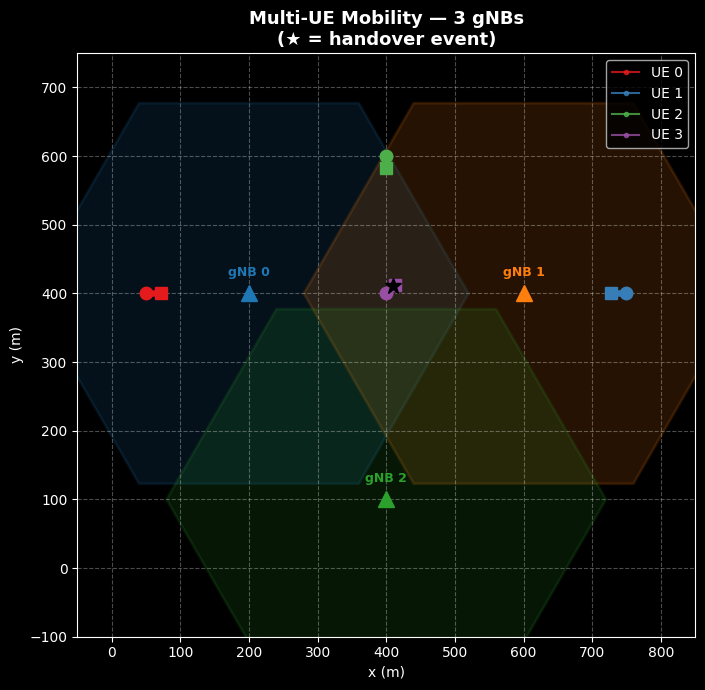

Total handovers: 1
  step  40: UE 3 gNB 0 → 1


In [42]:
# ── Plot 3: Multiple UEs with different trajectories ───────────────────────
env3 = MultiGNBWrapper(
    gnb_list=[
        MockNodeB(id=0, x=200, y=400, coverage_radius=320),
        MockNodeB(id=1, x=600, y=400, coverage_radius=320),
        MockNodeB(id=2, x=400, y=100, coverage_radius=320),
    ],
    slots_per_step=50,
    handover_hysteresis=0.04,
    handover_ttt=2,
    verbose=False,
)
env3.reset()

# Register several UEs with different velocities
ue_specs = [
    (50,  400,  9.0,  0.0),   # left → right
    (750, 400, -9.0,  0.0),   # right → left
    (400, 600,  0.0, -7.0),   # top → bottom
    (400, 400,  5.0,  5.0),   # diagonal
]
ue_ids = [env3.add_ue(x, y, vx, vy) for x, y, vx, vy in ue_specs]

N_STEPS3 = 50
trajectories3   = {uid: [] for uid in ue_ids}
serving_logs3   = {uid: [] for uid in ue_ids}

for _ in range(N_STEPS3):
    env3.step(env3.action_space.sample())
    for uid in ue_ids:
        ue = env3._ues[uid]
        trajectories3[uid].append((ue['x'], ue['y']))
        serving_logs3[uid].append(ue['serving_gnb'])

# --- visualise ---
fig, ax = plt.subplots(figsize=(9, 7))
draw_cells(ax, env3.gnbs, colors=COLORS)

UE_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for k, uid in enumerate(ue_ids):
    traj = trajectories3[uid]
    xs = [p[0] for p in traj]
    ys = [p[1] for p in traj]
    ax.plot(xs, ys, '-o', color=UE_COLORS[k], markersize=3,
            linewidth=1.5, alpha=0.8, label=f'UE {uid}')
    ax.plot(xs[0], ys[0], 'o', color=UE_COLORS[k], markersize=9, zorder=6)
    ax.plot(xs[-1], ys[-1], 's', color=UE_COLORS[k], markersize=9, zorder=6)

# Mark handover events
for ev in env3.handover_log:
    step = ev['step']
    uid  = ev['ue_id']
    if step < len(trajectories3[uid]):
        hx, hy = trajectories3[uid][step]
        ax.plot(hx, hy, 'k*', markersize=12, zorder=8)

ax.set_xlim(-50, 850)
ax.set_ylim(-100, 750)
ax.set_title('Multi-UE Mobility — 3 gNBs\n(★ = handover event)', fontsize=13, fontweight='bold')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'Total handovers: {len(env3.handover_log)}')
for ev in env3.handover_log:
    print(f"  step {ev['step']:>3d}: UE {ev['ue_id']} gNB {ev['from_gnb']} → {ev['to_gnb']}")

---
## Part B — Real NodeB

Requires the full stack:
`node_b`, `slice_l1`, `slice_ran`, `channel_models`, `schedulers`, `traffic_generators`.

Adjust imports and parameters below to match your project layout.

In [43]:
# ── Imports (edit paths if needed) ────────────────────────────────────────
from numpy.random import default_rng
from itertools import count

from node_b       import NodeB
from slice_l1     import SliceL1eMBB, SliceL1mMTC
from slice_ran    import SliceRANeMBB, SliceRANmMTC
from channel_models import SINRSelectiveFading, MCSCodeset
from schedulers     import ProportionalFair

In [44]:
def make_gnb(gnb_id: int, x: float, y: float, seed: int = 42) -> NodeB:
    """
    Factory function — creates one real NodeB with one eMBB + one mMTC slice.
    Edit slice configs here to match your scenario.
    """
    rng          = default_rng(seed=seed)
    user_counter = count()
    slots_per_step = 50
    N_PRBS         = 100

    # ── eMBB slice ───────────────────────────────────────────────────────
    CBR_desc = {'lambda': 2.0/60, 't_mean': 30.0, 'bit_rate': 500_000}
    VBR_desc = {'lambda': 5.0/60, 't_mean': 30.0,
                'p_size': 1000, 'b_size': 500, 'b_rate': 1}
    SLA_embb = {'cbr_th': 10e6, 'cbr_prb': 20, 'cbr_queue': 1e5,
                'vbr_th': 15e6, 'vbr_prb': 30, 'vbr_queue': 1.5e5}
    state_vars_embb = ['cbr_traffic','cbr_th','cbr_prb','cbr_queue','cbr_snr',
                       'vbr_traffic','vbr_th','vbr_prb','vbr_queue','vbr_snr']
    norm_embb = {v: 1e6 for v in state_vars_embb}   # rough normalisation

    snr_gen   = SINRSelectiveFading(rng, 'macro_cell_urban_2GHz', n_prbs=N_PRBS)
    mcs       = MCSCodeset()
    scheduler = ProportionalFair(mcs)

    slice_ran_embb = SliceRANeMBB(
        rng, user_counter, 0, SLA_embb,
        CBR_desc, VBR_desc,
        state_vars_embb, norm_embb, slots_per_step
    )
    slice_l1_embb = SliceL1eMBB(rng, snr_gen, 50, [slice_ran_embb], scheduler)

    # ── mMTC slice ───────────────────────────────────────────────────────
    MTC_desc = {
        'n_devices'     : 500,
        'repetition_set': [2, 4, 8, 16, 32],
        'period_set'    : [1000, 5000, 10000, 20000]
    }
    SLA_mmtc        = {'delay': 300}
    state_vars_mmtc = ['devices', 'avg_rep', 'delay']
    norm_mmtc       = {v: 100 * slots_per_step for v in state_vars_mmtc}

    slice_ran_mmtc = SliceRANmMTC(
        rng, 1, SLA_mmtc, MTC_desc,
        state_vars_mmtc, norm_mmtc, slots_per_step
    )
    slice_l1_mmtc = SliceL1mMTC(50, [slice_ran_mmtc])

    return NodeB(
        id=gnb_id, x=x, y=y,
        slices_l1=[slice_l1_embb, slice_l1_mmtc],
        slots_per_step=slots_per_step,
        n_prbs=N_PRBS,
        coverage_radius=400,
    )

print('Factory defined — run the next cell to build gNBs.')

Factory defined — run the next cell to build gNBs.


In [45]:
# ── B.1 Sanity checks ─────────────────────────────────────────────────────
real_gnbs = [
    make_gnb(gnb_id=0, x=200, y=300, seed=10),
    make_gnb(gnb_id=1, x=600, y=300, seed=20),
    make_gnb(gnb_id=2, x=400, y=600, seed=30),
]

real_env = MultiGNBWrapper(
    gnb_list=real_gnbs,
    slots_per_step=50,
    handover_hysteresis=0.04,
    handover_ttt=3,
    verbose=True,
)

obs, info = real_env.reset(seed=0)
print('Observation space :', real_env.observation_space)
print('Action space      :', real_env.action_space)
print(f'obs shape={obs.shape}, dtype={obs.dtype}')
assert obs.shape == real_env.observation_space.shape

# Run a few steps
for i in range(5):
    action = real_env.action_space.sample()
    obs, reward, _, _, info = real_env.step(action)
    print(f'  step {i+1}: reward={reward:.3f}  per_gnb={[round(r,3) for r in info["per_gnb_rewards"]]}')

print('\nReal NodeB sanity checks passed ✓')

Observation space : Box(-inf, inf, (45,), float32)
Action space      : Box(0.0, 1.0, (6,), float32)
obs shape=(45,), dtype=float32
  step 1: reward=1.000  per_gnb=[1.0, 1.0, 1.0]
  step 2: reward=1.000  per_gnb=[1.0, 1.0, 1.0]
  step 3: reward=1.000  per_gnb=[1.0, 1.0, 1.0]
  step 4: reward=1.000  per_gnb=[1.0, 1.0, 1.0]
  step 5: reward=1.000  per_gnb=[1.0, 1.0, 1.0]

Real NodeB sanity checks passed ✓


[UE added] id=0 pos=(50.0,300.0) serving_gnb=0
[UE added] id=1 pos=(750.0,300.0) serving_gnb=1


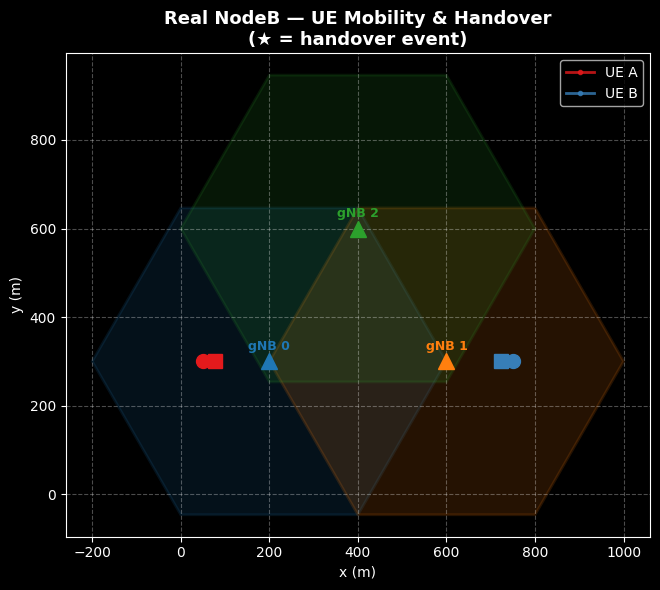

Handovers: 0


In [46]:
# ── B.2 UE mobility & handover visualisation (same as Part A, real env) ───
real_env.reset()

# Two UEs crossing between cells
uid_a = real_env.add_ue(x=50,  y=300, vx=9.0, vy=0.0)
uid_b = real_env.add_ue(x=750, y=300, vx=-9.0, vy=0.0)

N = 60
traj_a, traj_b = [], []
srv_a,  srv_b  = [], []

for _ in range(N):
    real_env.step(real_env.action_space.sample())
    ua = real_env._ues[uid_a]
    ub = real_env._ues[uid_b]
    traj_a.append((ua['x'], ua['y']));  srv_a.append(ua['serving_gnb'])
    traj_b.append((ub['x'], ub['y']));  srv_b.append(ub['serving_gnb'])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
draw_cells(ax, real_env.gnbs, colors=COLORS)

for traj, color, label in [(traj_a, '#e41a1c', 'UE A'), (traj_b, '#377eb8', 'UE B')]:
    xs = [p[0] for p in traj]
    ys = [p[1] for p in traj]
    ax.plot(xs, ys, '-o', color=color, markersize=3, linewidth=2, alpha=0.8, label=label)
    ax.plot(xs[0],  ys[0],  'o', color=color, markersize=10, zorder=6)
    ax.plot(xs[-1], ys[-1], 's', color=color, markersize=10, zorder=6)

all_trajs = {uid_a: traj_a, uid_b: traj_b}
for ev in real_env.handover_log:
    t = all_trajs.get(ev['ue_id'])
    if t and ev['step'] < len(t):
        ax.plot(*t[ev['step']], 'k*', markersize=14, zorder=8)

ax.set_title('Real NodeB — UE Mobility & Handover\n(★ = handover event)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Handovers: {len(real_env.handover_log)}')
for ev in real_env.handover_log:
    print(f"  step {ev['step']:>3d}: UE {ev['ue_id']} gNB {ev['from_gnb']} → {ev['to_gnb']}")